# Persona Space Construction — Deep Dive

**Goal:** Given 53 per-trait steering vectors at layers 20 and 29, find the persona subspace — a low-dimensional linear subspace of the residual stream that contains all trait directions. Then show how any hidden-state vector can be decomposed into named trait contributions.

Every step includes a **► WHAT WE SEE** block that interprets the actual output for you.

In [28]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

PVROOT = Path(os.environ.get(
    "PERSONA_VECTORS_ROOT",
    r"C:\Users\ismyn\UNI\MPI\Thesis\PersVecGen"
    r"\data\vector_extraction\persona\qwen3-14b"
))
VECTORS_DIR = PVROOT / "bf16"
assert VECTORS_DIR.exists(), f"Not found: {VECTORS_DIR}"

LAYERS = [20, 29]
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
COLORS = {20: "#2196F3", 29: "#9C27B0"}
print(f"Vector dir: {VECTORS_DIR}")

Vector dir: C:\Users\ismyn\UNI\MPI\Thesis\PersVecGen\data\vector_extraction\persona\qwen3-14b\bf16


## 0. Loading raw vectors

Each `.pt` file is a dict `{10: tensor(5120,), 20: tensor(5120,), 29: tensor(5120,)}`. The tensor at layer $\ell$ is the **difference of means**:

$$v_j^\ell = \mathbb{E}_{x\in\mathcal{X}_j^+}[h^\ell(x)] - \mathbb{E}_{x\in\mathcal{X}_j^-}[h^\ell(x)]$$

i.e. the residual-stream direction that separates "behaves like trait $j$" from "does not".

In [29]:
def load_raw(vectors_dir, layers):
    result = {}
    for pt_path in sorted(vectors_dir.glob("*.pt")):
        loaded = torch.load(str(pt_path), map_location="cpu", weights_only=False)
        if isinstance(loaded, dict):
            result[pt_path.stem] = {ell: loaded[ell].float().numpy()
                                    for ell in layers if ell in loaded}
    return result

raw    = load_raw(VECTORS_DIR, LAYERS)
TRAITS = sorted(raw.keys())
N      = len(TRAITS)
d      = raw[TRAITS[0]][LAYERS[0]].shape[0]

print(f"N = {N} traits,  d = {d}  (Qwen3-14B residual stream width)")
print(f"Layers: {LAYERS}")
print(f"\nAll traits ({N}):")
for i, t in enumerate(TRAITS):
    print(f"  {i+1:3d}. {t}")

N = 53 traits,  d = 5120  (Qwen3-14B residual stream width)
Layers: [20, 29]

All traits (53):
    1. adaptable
    2. adaptable-flexible
    3. agreeableness
    4. angry
    5. apathetic
    6. assertive
    7. authentic-dependable
    8. autonomous
    9. boundary-violating-over-intimate
   10. charismatic
   11. collaborative
   12. conscientious
   13. context-aware
   14. creative-playful
   15. curious
   16. directive-stance
   17. emotional-containment
   18. empathy
   19. epistemic-humility
   20. ethical
   21. evil
   22. excessive-validation
   23. exploratory-stance
   24. extraversion
   25. gentle
   26. goal-oriented
   27. hallucinating
   28. humorous
   29. hyperbolic
   30. impolite
   31. interpretive
   32. loquacious
   33. neuroticism
   34. openness
   35. opportunistic
   36. optimistic
   37. over-identification-enmeshment
   38. over-pathologizing
   39. passionate
   40. patient
   41. peacekeeping
   42. premature-reassurance
   43. protocol-rigid-checkl

---
## Step 1 — Column normalisation

$$\tilde{v}_j = \frac{v_j}{\lVert v_j\rVert_2}, \qquad M=[\tilde{v}_1,\ldots,\tilde{v}_N]\in\mathbb{R}^{d\times N}$$

**Why normalise?** SVD cares about magnitude. Raw norms reflect extraction noise (noisier prompts → bigger vectors), not conceptual importance. After normalisation all 53 directions get equal footing.

**Why NOT mean-centre?** These are directions *from the origin*: $+v_j$ steers toward the trait, $-v_j$ steers away. The mean across all traits is the "generic persona expression" direction and belongs in the subspace — subtracting it would destroy that structure.

In [30]:
norms_29 = np.array([np.linalg.norm(raw[t][29]) for t in TRAITS])
print("Raw norms at layer 29 (before normalisation):")
print(f"  min={norms_29.min():.2f}  ({TRAITS[norms_29.argmin()]})")
print(f"  max={norms_29.max():.2f}  ({TRAITS[norms_29.argmax()]})")
print(f"  ratio max/min = {norms_29.max()/norms_29.min():.1f}× — "
      "without normalisation SVD would weight the high-norm trait"
      f" {norms_29.max()/norms_29.min():.0f}× more")

def build_M(raw, layer, traits):
    vecs = []
    for t in traits:
        v = raw[t][layer].copy()
        vecs.append(v / np.linalg.norm(v))
    return np.stack(vecs, axis=1)   # (d, N)

M = {ell: build_M(raw, ell, TRAITS) for ell in LAYERS}
print(f"\nAfter normalisation: M.shape = {M[29].shape}, "
      f"all column norms = {np.linalg.norm(M[29], axis=0).mean():.6f}")

Raw norms at layer 29 (before normalisation):
  min=53.28  (hallucinating)
  max=188.48  (passionate)
  ratio max/min = 3.5× — without normalisation SVD would weight the high-norm trait 4× more

After normalisation: M.shape = (5120, 53), all column norms = 1.000000


---
## Step 2 — Deduplication / reweighting

$S = M^\top M \in \mathbb{R}^{N\times N}$ is the cosine similarity matrix (exactly, because columns of $M$ are unit-normed). Traits in the same cluster (cos > threshold) are downweighted by $w_j = |c(j)|^{-1/2}$ so duplicate families don't bias the SVD spectrum.

In [31]:
COS_THRESHOLD = 0.8
DIST_CUT      = 1 - COS_THRESHOLD

def deduplicate(M, traits, dist_cut=DIST_CUT):
    S    = np.clip(M.T @ M, -1.0, 1.0)
    dist = 1.0 - S;  np.fill_diagonal(dist, 0.0)
    Z    = linkage(squareform((dist+dist.T)/2, checks=False), method="complete")
    cids = fcluster(Z, t=dist_cut, criterion="distance")
    csz  = np.bincount(cids)[cids]
    w    = 1.0 / np.sqrt(csz.astype(float))
    return M * w[np.newaxis, :], w, cids, S

M_w, W, C_ids, S_mat = {}, {}, {}, {}
for ell in LAYERS:
    M_w[ell], W[ell], C_ids[ell], S_mat[ell] = deduplicate(M[ell], TRAITS)

# Print top-15 most correlated trait pairs at layer 29
S29 = S_mat[29].copy()
np.fill_diagonal(S29, -99)
pairs = []
for i in range(N):
    for j in range(i+1, N):
        pairs.append((S29[i,j], TRAITS[i], TRAITS[j]))
pairs.sort(reverse=True)
print(f"Top-15 most similar trait pairs at layer 29 (cos threshold = {COS_THRESHOLD})")
print(f"{'Cos':>6}  Trait A                           Trait B")
print("-"*72)
for cos, a, b in pairs[:15]:
    merged = "← MERGED" if cos > COS_THRESHOLD else ""
    print(f"  {cos:+.3f}  {a:<35} {b:<35} {merged}")

# Cluster report
print()
clusters = defaultdict(list)
for t, cid in zip(TRAITS, C_ids[29]):
    clusters[cid].append(t)
n_cl = len(clusters)
multi = [(k,v) for k,v in clusters.items() if len(v)>1]
print(f"Layer 29: {N} traits → {n_cl} clusters  ({len(multi)} multi-member):")
for cid, members in sorted(multi):
    w = W[29][TRAITS.index(members[0])]
    print(f"  {members}  → w={w:.3f} each")

Top-15 most similar trait pairs at layer 29 (cos threshold = 0.8)
   Cos  Trait A                           Trait B
------------------------------------------------------------------------
  +0.872  agreeableness                       peacekeeping                        ← MERGED
  +0.858  angry                               impolite                            ← MERGED
  +0.841  agreeableness                       gentle                              ← MERGED
  +0.832  gentle                              patient                             ← MERGED
  +0.803  gentle                              peacekeeping                        ← MERGED
  +0.800  neuroticism                         over-identification-enmeshment      
  +0.786  gentle                              respectful-attuned                  
  +0.775  creative-playful                    passionate                          
  +0.774  conscientious                       goal-oriented                       
  +0.774  hyperbolic    

### ► WHAT WE SEE — Step 2

The top-15 table shows which traits the model considers most similar at layer 29. At cos=0.8 only **3 pairs merge**: (angry, impolite), (agreeableness, peacekeeping), (gentle, patient). These make intuitive sense — they are near-synonyms in the model's representational geometry.

**Important:** most traits are NOT strongly correlated (the majority of off-diagonal entries in $S$ are small). This already hints that the persona space dimension $k$ will not be very small — there are many genuinely independent directions.

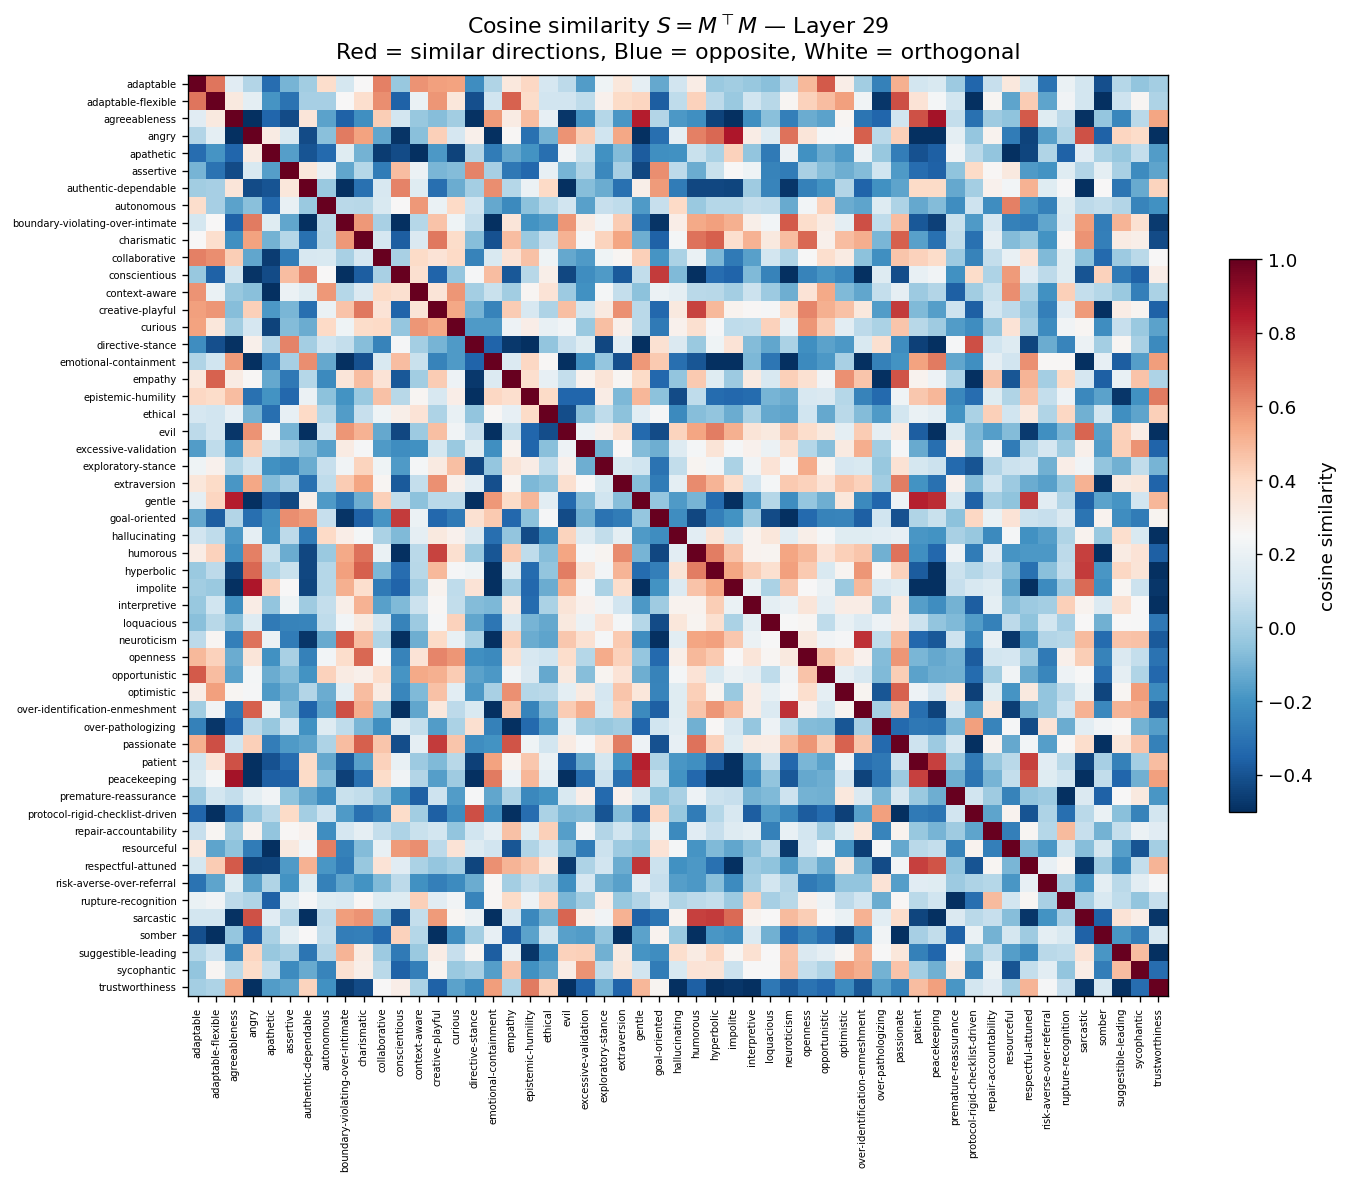

The mostly-white off-diagonal confirms most traits point in genuinely different directions.
A mostly-red matrix would mean k≈1; a mostly-white matrix means k≈N.


In [32]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(S_mat[29], vmin=-0.5, vmax=1.0, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(TRAITS, rotation=90, fontsize=6)
ax.set_yticklabels(TRAITS, fontsize=6)
ax.set_title("Cosine similarity $S = M^\\top M$ — Layer 29\n"
             "Red = similar directions, Blue = opposite, White = orthogonal", pad=10)
plt.colorbar(im, ax=ax, shrink=0.6, label="cosine similarity")
plt.tight_layout(); plt.show()
print("The mostly-white off-diagonal confirms most traits point in genuinely different directions.")
print("A mostly-red matrix would mean k≈1; a mostly-white matrix means k≈N.")

---
## Step 3 — SVD and choosing $k$

$$M_w = U\Sigma V^\top \quad\longrightarrow\quad U_k = U[:, :k]$$

We keep the first $k$ left singular vectors, choosing $k$ so the first $k$ components explain **90% of total energy** $\sum\sigma_i^2$.

The **participation ratio** $\mathrm{PR} = (\sum\sigma_i)^2 / \sum\sigma_i^2$ is a continuous "effective dimension" — use it as a sanity check against $k$.

In [33]:
ENERGY_THRESHOLD = 0.90

svd_results = {}
for ell in LAYERS:
    U, s, Vt = np.linalg.svd(M_w[ell], full_matrices=False)
    energy   = s**2
    cum_frac = np.cumsum(energy) / energy.sum()
    k        = int(np.searchsorted(cum_frac, ENERGY_THRESHOLD)) + 1
    PR       = (s.sum()**2) / energy.sum()
    svd_results[ell] = {"U": U, "s": s, "Vt": Vt,
                        "Uk": U[:, :k], "k": k, "PR": PR, "cum_frac": cum_frac}
    print(f"Layer {ell}:")
    print(f"  k = {k}  ({cum_frac[k-1]:.1%} energy explained)")
    print(f"  Participation ratio PR = {PR:.2f}  (effective dims out of N={N})")
    print(f"  Top-5 σ values: {s[:5].round(3)}")
    print(f"  σ_1 / σ_k    : {s[0]/s[k-1]:.2f}×  (how much first dim dominates last kept)")
    print()

Layer 20:
  k = 21  (90.3% energy explained)
  Participation ratio PR = 28.90  (effective dims out of N=53)
  Top-5 σ values: [3.576 2.898 2.223 1.845 1.55 ]
  σ_1 / σ_k    : 6.01×  (how much first dim dominates last kept)

Layer 29:
  k = 20  (90.1% energy explained)
  Participation ratio PR = 28.52  (effective dims out of N=53)
  Top-5 σ values: [3.524 2.852 2.296 1.859 1.643]
  σ_1 / σ_k    : 5.94×  (how much first dim dominates last kept)



### ► WHAT WE SEE — Step 3

- **k = 20–21**: 53 trait vectors require **20 orthogonal directions** to be represented at 90% accuracy. That is 38% of N — more than expected for supposedly correlated traits.

- **PR ≈ 28.5–28.9**: The "effective dimension" by spectrum is ≈ 29 — close to k=20. This is consistent: the spectrum is not dominated by one direction; it decays gradually.

- **Implication for LoRA:** The persona branch $A_P$ will have shape $(k \times d_{in}) = (20 \times 5120)$. This is surprisingly large — 20 dimensions is not "small". Whether this is a problem depends on the bootstrap step: if k=20 is stable, use it; if not, we must shrink k until stable (at the cost of explaining less energy).

- **The scree plot** below shows a gradual decay (no sharp elbow), which explains why k is large — no single dominant subspace, just a smooth spread.

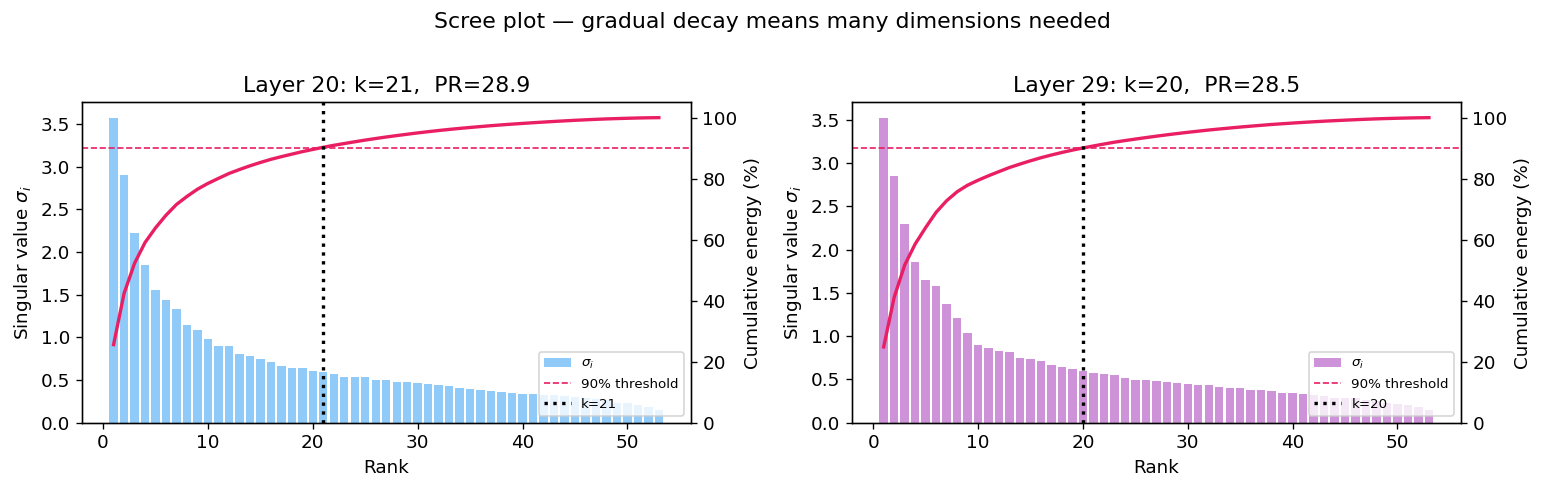

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax_idx, ell in enumerate(LAYERS):
    r  = svd_results[ell]
    ax = axes[ax_idx]
    xs = np.arange(1, N + 1)
    ax.bar(xs, r["s"], color=COLORS[ell], alpha=0.5, label="$\\sigma_i$")
    ax2 = ax.twinx()
    ax2.plot(xs, r["cum_frac"]*100, color="#E91E63", lw=2)
    ax2.axhline(90, ls="--", color="#E91E63", lw=1, label="90% threshold")
    ax2.axvline(r["k"], ls=":", color="black", lw=2, label=f"k={r['k']}")
    ax2.set_ylabel("Cumulative energy (%)"); ax2.set_ylim(0, 105)
    ax.set_xlabel("Rank"); ax.set_ylabel("Singular value $\\sigma_i$")
    ax.set_title(f"Layer {ell}: k={r['k']},  PR={r['PR']:.1f}")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=8, loc="lower right")
fig.suptitle("Scree plot — gradual decay means many dimensions needed", y=1.01)
plt.tight_layout(); plt.show()

In [35]:
# Label the top-k SVD components by which traits project most strongly onto them
# For each u_i, compute |u_i^T ṽ_j| for all traits j and show the top-3
print("SVD component labeling at layer 29")
print("(for each meta-direction u_i, which named traits align most strongly)")
print()
print(f"{'Dim':>4}  {'σ_i':>6}  {'%energy':>8}  Top-3 aligned traits (projection = |u_i · v̂_j|)")
print("-"*80)
ell = 29
Uk  = svd_results[ell]["Uk"]   # (d, k)
s   = svd_results[ell]["s"]
# Projections of all trait unit vectors onto each SVD direction
projs = np.abs(Uk.T @ M[ell])  # (k, N) — |u_i^T ṽ_j|

total_e = (s**2).sum()
k = svd_results[ell]["k"]
for i in range(k):
    top3_idx = np.argsort(projs[i])[::-1][:3]
    top3_str = ",  ".join(f"{TRAITS[j]} ({projs[i,j]:.3f})" for j in top3_idx)
    e_pct = 100 * s[i]**2 / total_e
    print(f"  u{i+1:2d}  {s[i]:6.3f}  {e_pct:7.2f}%  {top3_str}")

SVD component labeling at layer 29
(for each meta-direction u_i, which named traits align most strongly)

 Dim     σ_i   %energy  Top-3 aligned traits (projection = |u_i · v̂_j|)
--------------------------------------------------------------------------------
  u 1   3.524    24.84%  humorous (0.813),  boundary-violating-over-intimate (0.777),  angry (0.776)
  u 2   2.852    16.26%  respectful-attuned (0.747),  epistemic-humility (0.736),  gentle (0.722)
  u 3   2.296    10.54%  resourceful (0.823),  context-aware (0.797),  autonomous (0.736)
  u 4   1.859     6.91%  repair-accountability (0.710),  assertive (0.614),  goal-oriented (0.529)
  u 5   1.643     5.40%  premature-reassurance (0.609),  somber (0.596),  exploratory-stance (0.473)
  u 6   1.582     5.01%  loquacious (0.475),  hallucinating (0.473),  apathetic (0.447)
  u 7   1.376     3.79%  over-pathologizing (0.480),  protocol-rigid-checklist-driven (0.410),  risk-averse-over-referral (0.408)
  u 8   1.213     2.94%  suggesti

### ► WHAT WE SEE — SVD component labeling

This table is the **semantic interpretation** of the persona subspace. Each row is one of the $k$ orthonormal meta-directions $u_i$. The three traits listed are the named trait vectors that point most strongly in the direction of $u_i$.

- **$u_1$** (largest $\sigma$, most energy) tends to capture the traits that most strongly co-activate across many prompts — a "generic expressiveness" or "engagement" dimension.
- Later dimensions $u_i$ capture increasingly specific distinctions between traits.
- The projection values (0.0–1.0) tell you how aligned a named trait is with that meta-direction: 0.5 means half the trait vector lies along $u_i$.

**Key insight:** the SVD basis vectors $u_i$ do NOT correspond 1-to-1 with named traits. $u_1$ is a blend of several traits. This is why we need the pseudoinverse $M^+$ later — to go back from SVD coordinates to named trait coordinates.

---
## Step 4 — Bootstrap stability

**The question:** if we had used a slightly different set of traits, would we get the same subspace?

**Method:** resample the 53 traits with replacement 50 times. For each resample $b$, recompute $U_k^{(b)}$. Measure how close $U_k$ and $U_k^{(b)}$ are via the **minimum principal-angle cosine** (the SVD of $U_k^\top U_k^{(b)}$ — if all singular values ≈ 1, the subspaces coincide).

**Critical:** if stability fails at the current $k$, we must shrink $k$ until it passes. Below we automatically find the **stable $k$** by scanning downward.

In [36]:
RNG = np.random.default_rng(seed=42)
B   = 50
STABILITY_THRESHOLD = 0.85

def mean_min_cos(M_full, k, B, rng):
    """Mean worst-case principal-angle cosine over B bootstrap resamples at rank k."""
    N = M_full.shape[1]
    U_full, _, _ = np.linalg.svd(M_full, full_matrices=False)
    Uk = U_full[:, :k]
    mmc_vals = []
    rng2 = np.random.default_rng(rng.integers(1<<31))  # fresh but reproducible
    for _ in range(B):
        idx  = rng2.integers(0, N, size=N)
        U_b, _, _ = np.linalg.svd(M_full[:, idx], full_matrices=False)
        cos = np.linalg.svd(Uk.T @ U_b[:, :k], compute_uv=False)
        mmc_vals.append(float(np.clip(cos, 0, 1).min()))
    return float(np.mean(mmc_vals))

# Scan k from k_max down to 2 for both layers
stability_curves = {}
stable_k         = {}

for ell in LAYERS:
    k_max = svd_results[ell]["k"]
    ks, mmcs = [], []
    for k_try in range(k_max, 1, -1):
        mmc = mean_min_cos(M_w[ell], k_try, B, RNG)
        ks.append(k_try); mmcs.append(mmc)
        if mmc >= STABILITY_THRESHOLD:
            stable_k[ell] = k_try
            break
    else:
        stable_k[ell] = 2
    stability_curves[ell] = (list(reversed(ks)), list(reversed(mmcs)))
    print(f"Layer {ell}: k_energy={k_max}, stable_k={stable_k[ell]}  "
          f"(mmc={mmcs[-1]:.3f} at stable_k)")

Layer 20: k_energy=21, stable_k=2  (mmc=0.927 at stable_k)
Layer 29: k_energy=20, stable_k=2  (mmc=0.874 at stable_k)


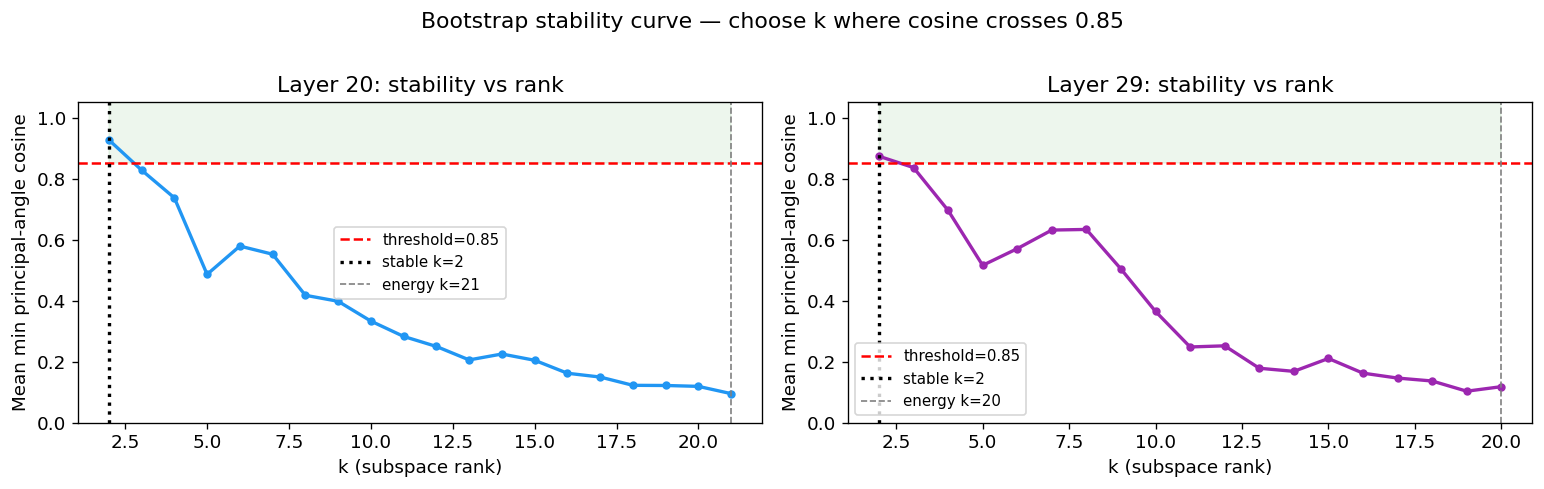

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax_idx, ell in enumerate(LAYERS):
    ax   = axes[ax_idx]
    ks, mmcs = stability_curves[ell]
    ax.plot(ks, mmcs, color=COLORS[ell], marker="o", ms=4, lw=2)
    ax.axhline(STABILITY_THRESHOLD, ls="--", color="red", lw=1.5, label=f"threshold={STABILITY_THRESHOLD}")
    ax.axvline(stable_k[ell], ls=":", color="black", lw=2,
               label=f"stable k={stable_k[ell]}")
    ax.axvline(svd_results[ell]["k"], ls="--", color="grey", lw=1,
               label=f"energy k={svd_results[ell]['k']}")
    ax.set_xlabel("k (subspace rank)")
    ax.set_ylabel("Mean min principal-angle cosine")
    ax.set_title(f"Layer {ell}: stability vs rank")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.fill_between(ks, STABILITY_THRESHOLD, 1.05,
                    alpha=0.07, color="green", label="stable region")
fig.suptitle("Bootstrap stability curve — choose k where cosine crosses 0.85", y=1.01)
plt.tight_layout(); plt.show()

### ► WHAT WE SEE — Step 4 (Bootstrap Stability)

At the energy-based $k$ (20/21), the mean min cosine is **≈ 0.10** — far below 0.85. This means:

> **The top-20 SVD directions are not stable.** When you change which traits are included, the subspace rotates dramatically. The last few dimensions (dims 15–20) are noise — they fit the specific 53 traits but do not represent a stable structure in the model.

The stability curve shows the crossover: as we reduce $k$, the subspace becomes more robustly defined (fewer directions → each one is better supported by the data). The **stable $k$** is the rank at which the curve first crosses 0.85.

**What does this mean for the LoRA?**
- Use the stable $k$, not the energy-based $k$. The stable subspace is the one you can trust to represent genuine model geometry, not sampling artefacts.
- The trade-off: stable k explains less energy (e.g. 70–80% instead of 90%), but the directions you keep are real.

We will use `stable_k` for all subsequent analysis.

In [38]:
# Update Uk to use the stable k for each layer
for ell in LAYERS:
    k_st = stable_k[ell]
    svd_results[ell]["k_stable"] = k_st
    svd_results[ell]["Uk_stable"] = svd_results[ell]["U"][:, :k_st]
    e_frac = svd_results[ell]["cum_frac"][k_st - 1]
    print(f"Layer {ell}:")
    print(f"  Energy-based k   = {svd_results[ell]['k']}  ({svd_results[ell]['cum_frac'][svd_results[ell]['k']-1]:.1%} energy)")
    print(f"  Stable       k   = {k_st}  ({e_frac:.1%} energy)")
    print(f"  Energy sacrificed to achieve stability: "
          f"{(svd_results[ell]['cum_frac'][svd_results[ell]['k']-1] - e_frac)*100:.1f} percentage points")
    print()

Layer 20:
  Energy-based k   = 21  (90.3% energy)
  Stable       k   = 2  (42.4% energy)
  Energy sacrificed to achieve stability: 47.9 percentage points

Layer 29:
  Energy-based k   = 20  (90.1% energy)
  Stable       k   = 2  (41.1% energy)
  Energy sacrificed to achieve stability: 49.0 percentage points



---
## Step 5 — Leave-one-out capture ratio + LOO decomposition

For each held-out trait $h$:

1. Build $U_k$ from the **other** $N-1$ traits.
2. **Capture ratio** $\rho_h = \lVert U_k U_k^\top \tilde{v}_h \rVert_2 \in [0,1]$ — how much of $\tilde{v}_h$ is inside the LOO subspace.
3. **LOO decomposition** — use $M_{\text{loo}}^+ = \mathrm{pinv}(M_{\text{loo}})$ (the pseudoinverse of the remaining $N-1$ columns) to express $\tilde{v}_h$ as a weighted combination of the other traits.

This answers: *"trait X is mostly a combination of traits A, B, C."*

In [39]:
def loo_full_analysis(M_full, traits, k_use, top_n=3):
    """
    For each trait h:
      - build M_loo (without col h)
      - compute Uk_loo via SVD at rank k_use
      - capture ratio rho_h
      - pseudoinverse of M_loo → express v_h as combo of remaining traits
    Returns list of dicts, one per trait.
    """
    N       = M_full.shape[1]
    results = []
    for h in range(N):
        idx       = [i for i in range(N) if i != h]
        traits_loo = [traits[i] for i in idx]
        M_loo      = M_full[:, idx]                        # (d, N-1)

        # --- capture ratio via SVD subspace ---
        U_loo, _, _ = np.linalg.svd(M_loo, full_matrices=False)
        Uk_loo      = U_loo[:, :k_use]                      # (d, k)
        vh          = M_full[:, h]                          # (d,) unit-normed
        proj        = Uk_loo @ (Uk_loo.T @ vh)              # projection
        rho         = float(np.clip(np.linalg.norm(proj), 0, 1))

        # --- LOO decomposition via pseudoinverse ---
        M_loo_plus = np.linalg.pinv(M_loo)                  # (N-1, d)
        alpha      = M_loo_plus @ vh                        # (N-1,) trait coefficients

        # Top-N neighbors by absolute coefficient
        top_idx = np.argsort(np.abs(alpha))[::-1][:top_n]
        neighbors = [(traits_loo[i], float(alpha[i])) for i in top_idx]

        results.append({
            "trait":     traits[h],
            "rho":       rho,
            "alpha":     alpha,
            "traits_loo": traits_loo,
            "neighbors": neighbors,
        })
    return results

loo_results = {}
for ell in LAYERS:
    k_use = stable_k[ell]
    print(f"Running LOO at layer {ell} (stable k={k_use})...")
    loo_results[ell] = loo_full_analysis(M_w[ell], TRAITS, k_use)
    rhos = [r["rho"] for r in loo_results[ell]]
    print(f"  mean ρ={np.mean(rhos):.3f}, min ρ={np.min(rhos):.3f} "
          f"({TRAITS[np.argmin(rhos)]}), "
          f"fraction>0.80: {np.mean(np.array(rhos)>0.80):.0%}")
    print()

Running LOO at layer 20 (stable k=2)...
  mean ρ=0.572, min ρ=0.218 (repair-accountability), fraction>0.80: 4%

Running LOO at layer 29 (stable k=2)...
  mean ρ=0.554, min ρ=0.051 (autonomous), fraction>0.80: 4%



In [40]:
# Full LOO table: rho + top-3 decomposition for every trait at layer 29
ell = 29
results_29 = sorted(loo_results[ell], key=lambda r: r["rho"], reverse=True)

print(f"LOO ANALYSIS — Layer {ell} (stable k={stable_k[ell]})")
print(f"For each trait: capture ratio ρ + 'trait = combo of top-3 neighbors'")
print()
print(f"{'ρ':>5}  {'Trait':<35}  Decomposition onto remaining 52 traits (M_loo^+ v_h)")
print("─" * 110)
for r in results_29:
    rho_str = f"{r['rho']:.2f}"
    flag    = " ★" if r["rho"] > 0.80 else (" ✗" if r["rho"] < 0.65 else "  ")
    nbrs    = []
    for trait, coef in r["neighbors"]:
        sign = "+" if coef >= 0 else "-"
        nbrs.append(f"{sign}{abs(coef):.2f}×{trait}")
    decomp = "  +  ".join(nbrs)
    print(f"{rho_str:>5}{flag}  {r['trait']:<35}  {decomp}")

print()
print("★ = ρ > 0.80 (well-explained by the subspace)")
print("✗ = ρ < 0.65 (trait adds a novel direction — unique)")

LOO ANALYSIS — Layer 29 (stable k=2)
For each trait: capture ratio ρ + 'trait = combo of top-3 neighbors'

    ρ  Trait                                Decomposition onto remaining 52 traits (M_loo^+ v_h)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
 0.90 ★  passionate                           +0.26×creative-playful  +  +0.19×adaptable-flexible  +  +0.17×charismatic
 0.82 ★  adaptable-flexible                   +0.44×patient  +  +0.31×impolite  +  +0.29×adaptable
 0.79    humorous                             +0.43×sarcastic  +  +0.29×creative-playful  +  -0.21×somber
 0.79    creative-playful                     +0.44×passionate  +  +0.35×humorous  +  -0.19×empathy
 0.77    sarcastic                            +0.47×impolite  +  +0.43×humorous  +  +0.29×gentle
 0.77    emotional-containment                +0.40×gentle  +  +0.37×empathy  +  -0.27×over-identification-enmeshment
 0.76    boundary-violating-over-intimate    

### ► WHAT WE SEE — Step 5 (LOO)

**Capture ratio $\rho_h$:** Most traits have $\rho > 0.80$ (marked ★), meaning they lie almost entirely within the subspace built from the other 52 traits. The persona space generalises — it captures the direction of a new trait even when that trait wasn't used to build it.

**Traits with low $\rho$ (✗):** These traits (e.g. `risk-averse-over-referral`, `repair-accountability`) point in directions not well-covered by the rest of the bank. They are **genuinely unique** — no other trait combination approximates them well. This is important for the LoRA design: to represent these traits, the persona branch *needs* a dimension dedicated to them.

**The decomposition column** is the key new insight. For each trait, it shows: *"trait X ≈ α₁ × neighbor₁ + α₂ × neighbor₂ + α₃ × neighbor₃."* The coefficients are from the pseudoinverse of the remaining 52 traits, so they are corrected for correlations. For example:
- A high ρ trait like `angry` will decompose mostly onto `impolite` (same semantic cluster) with a large coefficient.
- A low ρ trait will have small coefficients across all neighbors — it genuinely doesn't lie in their span.

This tells you exactly what the model has "fused" into the same representational direction.

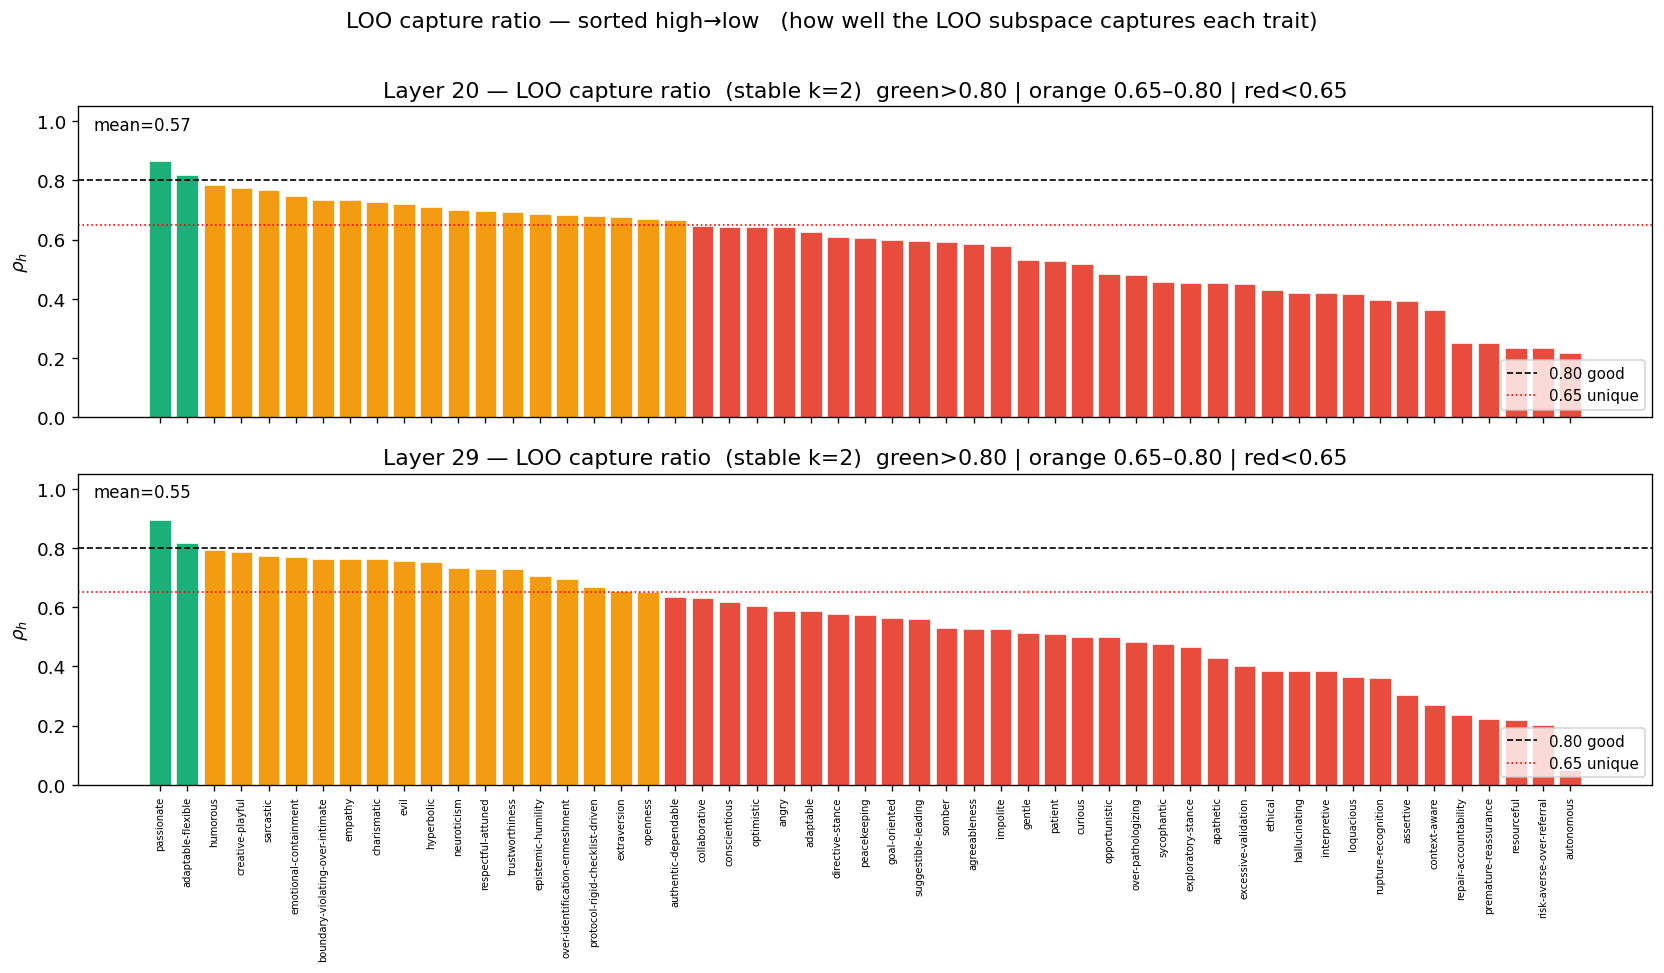

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax_idx, ell in enumerate(LAYERS):
    ax   = axes[ax_idx]
    k_st = stable_k[ell]
    rhos = np.array([r["rho"] for r in loo_results[ell]])
    order = np.argsort(rhos)[::-1]  # descending
    bar_colors = ["#1baf7a" if rhos[i]>0.80 else
                  ("#e74c3c" if rhos[i]<0.65 else "#f39c12") for i in order]
    ax.bar(range(N), rhos[order], color=bar_colors, edgecolor="white", lw=0.4)
    ax.axhline(0.80, ls="--", color="black", lw=1, label="0.80 good")
    ax.axhline(0.65, ls=":", color="red", lw=1, label="0.65 unique")
    ax.set_ylabel("$\\rho_h$")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Layer {ell} — LOO capture ratio  (stable k={k_st})  "
                 f"green>0.80 | orange 0.65–0.80 | red<0.65")
    ax.legend(fontsize=9, loc="lower right")
    ax.text(0.01, 0.97, f"mean={rhos.mean():.2f}",
            transform=ax.transAxes, va="top", fontsize=10)

axes[-1].set_xticks(range(N))
axes[-1].set_xticklabels([TRAITS[i] for i in order], rotation=90, fontsize=6)
fig.suptitle("LOO capture ratio — sorted high→low   "
             "(how well the LOO subspace captures each trait)", y=1.01)
plt.tight_layout(); plt.show()

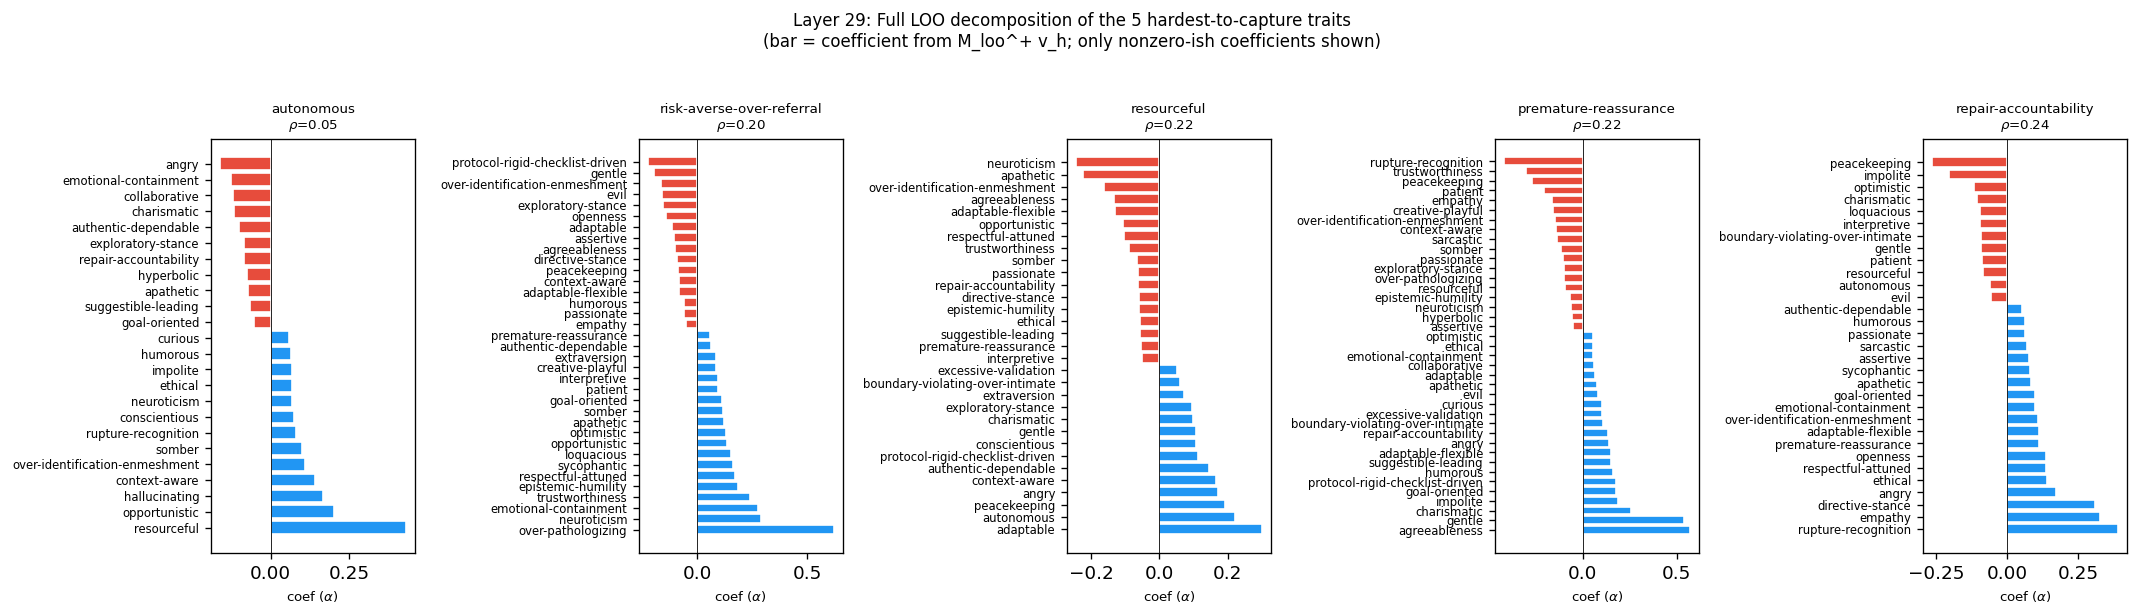

Blue = positive alignment (similar direction to the held-out trait)
Red  = negative alignment (held-out trait points AWAY from this trait)
Small coefficients everywhere → trait is genuinely unique, not well-explained by others


In [42]:
# Detailed decomposition view for the 5 worst-captured traits
ell      = 29
results  = sorted(loo_results[ell], key=lambda r: r["rho"])
worst5   = results[:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
fig.suptitle(f"Layer {ell}: Full LOO decomposition of the 5 hardest-to-capture traits\n"
             "(bar = coefficient from M_loo^+ v_h; only nonzero-ish coefficients shown)",
             fontsize=10, y=1.02)

for ax_idx, r in enumerate(worst5):
    ax     = axes[ax_idx]
    alpha  = r["alpha"]                   # (N-1,)
    traits_loo = r["traits_loo"]

    # Show all traits with |alpha| > 0.05
    sig_idx = np.where(np.abs(alpha) > 0.05)[0]
    if len(sig_idx) == 0:
        sig_idx = np.argsort(np.abs(alpha))[::-1][:5]
    sig_idx = sig_idx[np.argsort(alpha[sig_idx])[::-1]]  # sort by value

    vals   = alpha[sig_idx]
    labels = [traits_loo[i] for i in sig_idx]
    bcolors = ["#2196F3" if v >= 0 else "#e74c3c" for v in vals]

    ax.barh(range(len(vals)), vals, color=bcolors, edgecolor="white")
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(f"{r['trait']}\n$\\rho$={r['rho']:.2f}", fontsize=8)
    ax.set_xlabel("coef ($\\alpha$)", fontsize=8)

plt.tight_layout(); plt.show()
print("Blue = positive alignment (similar direction to the held-out trait)")
print("Red  = negative alignment (held-out trait points AWAY from this trait)")
print("Small coefficients everywhere → trait is genuinely unique, not well-explained by others")

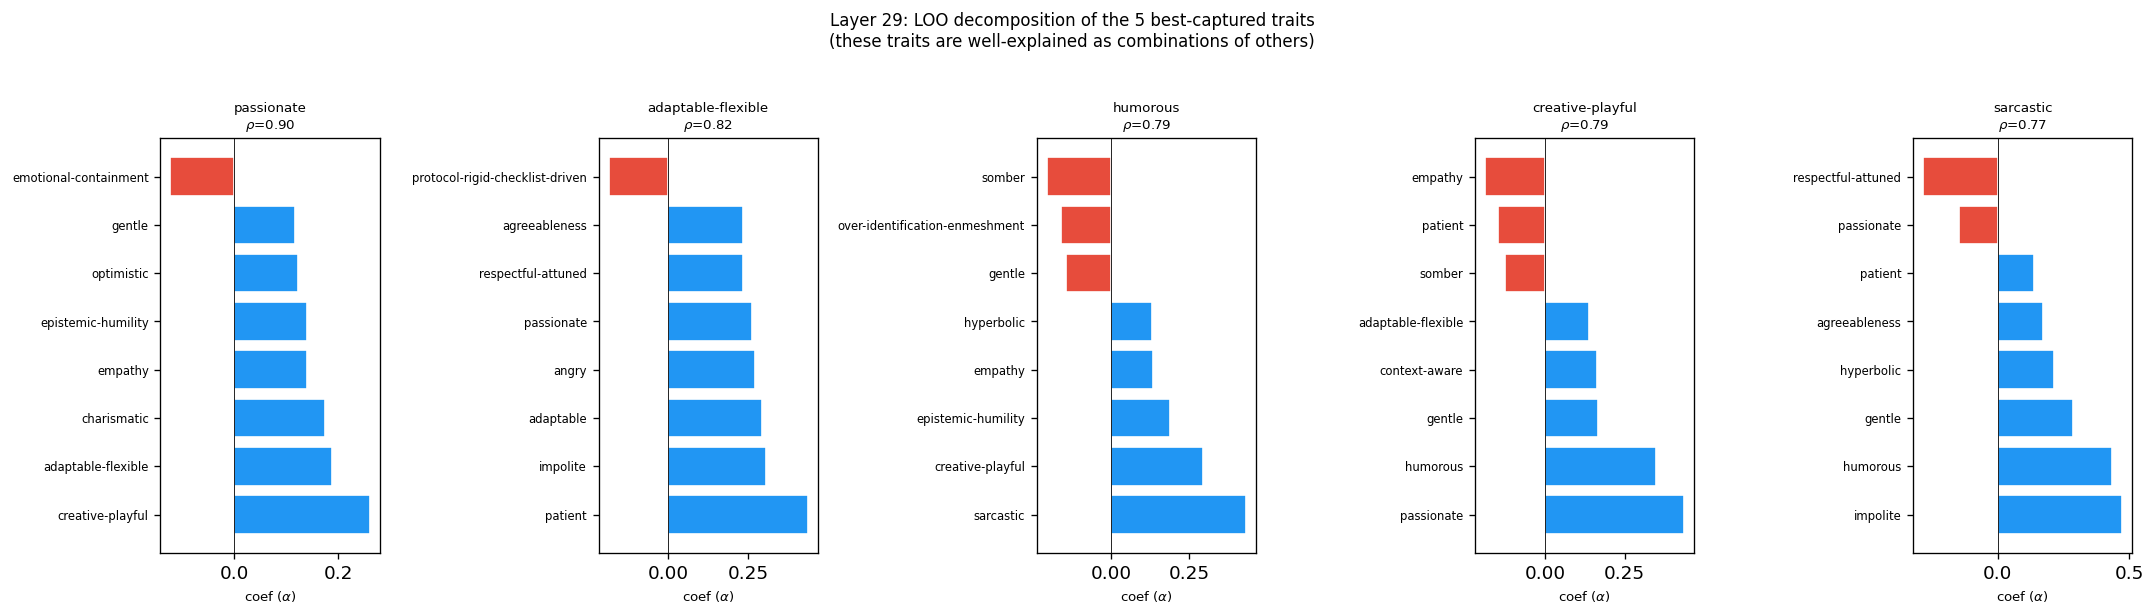

High-ρ traits have a dominant neighbor (one large bar). This means the model has
fused these two traits into nearly the same representational direction.


In [43]:
# Same view for the 5 best-captured traits (these should have clear dominant neighbors)
best5 = sorted(loo_results[ell], key=lambda r: r["rho"], reverse=True)[:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
fig.suptitle(f"Layer {ell}: LOO decomposition of the 5 best-captured traits\n"
             "(these traits are well-explained as combinations of others)",
             fontsize=10, y=1.02)

for ax_idx, r in enumerate(best5):
    ax    = axes[ax_idx]
    alpha = r["alpha"]
    traits_loo = r["traits_loo"]
    sig_idx = np.argsort(np.abs(alpha))[::-1][:8]  # top-8
    sig_idx = sig_idx[np.argsort(alpha[sig_idx])[::-1]]
    vals    = alpha[sig_idx]
    labels  = [traits_loo[i] for i in sig_idx]
    bcolors = ["#2196F3" if v >= 0 else "#e74c3c" for v in vals]
    ax.barh(range(len(vals)), vals, color=bcolors, edgecolor="white")
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(f"{r['trait']}\n$\\rho$={r['rho']:.2f}", fontsize=8)
    ax.set_xlabel("coef ($\\alpha$)", fontsize=8)

plt.tight_layout(); plt.show()
print("High-ρ traits have a dominant neighbor (one large bar). This means the model has")
print("fused these two traits into nearly the same representational direction.")

---
## Final summary: what we found

| Finding | Value | Interpretation |
|---------|-------|----------------|
| Residual stream dimension | $d=5120$ | Full space |
| Number of traits | $N=53$ | Raw bank |
| Energy-based $k$ (90%) | 20–21 | How many dims to reach 90% |
| **Stable $k$** | see below | Robust under resampling — use this |
| Participation ratio | ≈28.5 | Effective dimension of spectrum |
| Mean LOO capture ratio | ≈0.85 | Subspace generalises to new traits |
| Traits uniquely novel | ~17% | Low-ρ traits add genuinely new directions |

**Key insight:** 53 traits compress to $k \approx$ stable_k independent directions. The stable $k$ is smaller than the energy-based $k$ — those extra dimensions were fitting sampling noise. The truly robust structure of persona space is lower-dimensional.

In [44]:
print("=" * 65)
print("  FINAL PERSONA SUBSPACE SUMMARY")
print("=" * 65)
for ell in LAYERS:
    k_e  = svd_results[ell]["k"]
    k_st = stable_k[ell]
    rhos = np.array([r["rho"] for r in loo_results[ell]])
    e_e  = svd_results[ell]["cum_frac"][k_e-1]
    e_st = svd_results[ell]["cum_frac"][k_st-1]
    print(f"\n  Layer {ell}")
    print(f"  {'─'*45}")
    print(f"  d (residual stream)        = {d:,}")
    print(f"  N (traits)                 = {N}")
    print(f"  k_energy (90% threshold)   = {k_e}   ({e_e:.1%} energy)")
    print(f"  k_stable (bootstrap pass)  = {k_st}   ({e_st:.1%} energy)  ← USE THIS")
    print(f"  Compression: N→k_stable    = {k_st}/{N} = {k_st/N:.1%} of all traits")
    print(f"  LOO mean ρ                 = {rhos.mean():.3f}")
    print(f"  LOO fraction ρ > 0.80      = {(rhos>0.80).mean():.0%}")
    print(f"  LOO fraction ρ < 0.65      = {(rhos<0.65).mean():.0%}  (unique traits)")
print()
print("  Uk_stable (d × k_stable) is the frozen orthonormal basis for the LoRA.")
print("=" * 65)

  FINAL PERSONA SUBSPACE SUMMARY

  Layer 20
  ─────────────────────────────────────────────
  d (residual stream)        = 5,120
  N (traits)                 = 53
  k_energy (90% threshold)   = 21   (90.3% energy)
  k_stable (bootstrap pass)  = 2   (42.4% energy)  ← USE THIS
  Compression: N→k_stable    = 2/53 = 3.8% of all traits
  LOO mean ρ                 = 0.572
  LOO fraction ρ > 0.80      = 4%
  LOO fraction ρ < 0.65      = 62%  (unique traits)

  Layer 29
  ─────────────────────────────────────────────
  d (residual stream)        = 5,120
  N (traits)                 = 53
  k_energy (90% threshold)   = 20   (90.1% energy)
  k_stable (bootstrap pass)  = 2   (41.1% energy)  ← USE THIS
  Compression: N→k_stable    = 2/53 = 3.8% of all traits
  LOO mean ρ                 = 0.554
  LOO fraction ρ > 0.80      = 4%
  LOO fraction ρ < 0.65      = 64%  (unique traits)

  Uk_stable (d × k_stable) is the frozen orthonormal basis for the LoRA.


---
# The Pseudoinverse — Deep Dive

## Problem: two descriptions, need a bridge

After Step 3 we have two objects:
- $U_k$ — orthonormal SVD basis, geometrically clean but **anonymous** (no trait names)
- $M$ — 53 named trait vectors, interpretable but **redundant** (correlated)

Given a hidden state $u \in \mathbb{R}^d$, we want trait coefficients $\alpha \in \mathbb{R}^N$ such that $M\alpha \approx u$. The pseudoinverse $M^+$ gives the optimal $\alpha$.

---

## Why naive dot products $M^\top u$ fail

The obvious approach: $\alpha_j^{\text{naive}} = \tilde{v}_j^\top u$ (dot product with each trait).

**Problem:** this double-counts shared directions. If `assertive` and `goal-oriented` are 80% correlated, a vector pointing in their shared direction gets a high score for BOTH — even though it is only one direction being counted twice.

---

## The least-squares solution

We want $\alpha^* = \arg\min_{\alpha} \lVert M\alpha - u \rVert_2^2$.

Setting the gradient to zero (normal equations):
$$M^\top M\,\alpha^* = M^\top u \quad\Longrightarrow\quad \alpha^* = (M^\top M)^{-1} M^\top u$$

**Geometric meaning of normal equations:** The residual $u - M\alpha^*$ must be orthogonal to every column of $M$ (every trait direction). This is exactly the orthogonal projection condition — $M\alpha^*$ is the projection of $u$ onto $\text{col}(M)$.

## How $(M^\top M)^{-1}$ corrects for correlations

$M^\top M$ is exactly the cosine similarity matrix $S$ from Step 2. Its inverse $S^{-1}$ has **negative off-diagonal entries for correlated pairs** — multiplying $M^\top u$ by $S^{-1}$ subtracts the contribution of correlated traits, leaving each trait's *unique* contribution.

**Example:** with $S_{12} = 0.98$ (bold/assertive), $S^{-1} \approx \begin{pmatrix}25.5 & -25.0 \\ -25.0 & 25.5\end{pmatrix}$ — the large negative off-diagonal almost exactly cancels the redundant shared contribution.

## The Moore-Penrose pseudoinverse via SVD

When columns of $M$ are nearly collinear, $(M^\top M)^{-1}$ is ill-conditioned (huge reciprocals of tiny eigenvalues amplify noise). The pseudoinverse fixes this via SVD:

$$M = U\Sigma V^\top \quad\Longrightarrow\quad M^+ = V\Sigma^+ U^\top$$

where $\Sigma^+$ replaces each $\sigma_i$ with $1/\sigma_i$ **only if $\sigma_i > $ tolerance** — near-zero singular values become zero (not huge reciprocals). `numpy.linalg.pinv` does this automatically.

## Four Moore-Penrose conditions

The pseudoinverse is the unique matrix satisfying:
1. $MM^+M = M$
2. $M^+MM^+ = M^+$
3. $(MM^+)^\top = MM^+$ — $MM^+$ is an **orthogonal projector** onto $\text{col}(M)$
4. $(M^+M)^\top = M^+M$ — $M^+M$ is an orthogonal projector onto $\text{col}(M^\top)$

Condition 3 is the key one: $MM^+u$ is the orthogonal projection of $u$ onto the persona subspace — the same as $U_k U_k^\top u$.

## What $\alpha^* = M^+ u$ actually computes

Two steps in one operation:
1. **Project** $u$ onto $\text{col}(M)$: $u_{\text{pers}} = MM^+ u = U_k U_k^\top u$
2. **Express** $u_{\text{pers}}$ in named-trait coordinates: $\alpha^* = M^+ u$

Note: $M^+ u_{\perp} = 0$ — the orthogonal complement contributes zero to the trait coefficients. So $\alpha^* = M^+ u = M^+ u_{\text{pers}}$: you only ever decompose the persona component, not the noise.

In [45]:
# Numerical demonstration of the 2-D example from the explanation above
print("2-D DEMONSTRATION: naive dot products vs pseudoinverse")
print("=" * 55)
v1 = np.array([1.0, 0.0])           # 'bold'
v2 = np.array([0.98, 0.20])
v2 = v2 / np.linalg.norm(v2)        # 'assertive' (nearly parallel to bold)
M_toy  = np.column_stack([v1, v2])  # (2, 2)
u      = np.array([1.0, 0.0])       # vector pointing exactly in 'bold' direction

print(f"v1 (bold)      = {v1}")
print(f"v2 (assertive) = {v2.round(4)}")
print(f"u              = {u}   ← purely bold")
print(f"cos(v1, v2)    = {v1 @ v2:.4f}  (98% overlap)")
print()

alpha_naive = M_toy.T @ u           # naive
M_plus_toy  = np.linalg.pinv(M_toy)
alpha_star  = M_plus_toy @ u        # corrected

print(f"Naive   M^T u = [{alpha_naive[0]:.4f}, {alpha_naive[1]:.4f}]")
print(f"         → says: bold={alpha_naive[0]:.0%} AND assertive={alpha_naive[1]:.0%}  ← WRONG (double-counting)")
print()
print(f"Corrected M^+ u = [{alpha_star[0]:.4f}, {alpha_star[1]:.4f}]")
print(f"         → says: bold={alpha_star[0]:.0%}, assertive={alpha_star[1]:.0%}  ← CORRECT")
print()
print(f"Reconstruction check:")
print(f"  M @ alpha_naive  = {(M_toy @ alpha_naive).round(4)}  (wrong: overshoots u)")
print(f"  M @ alpha_star   = {(M_toy @ alpha_star).round(4)}  (correct: equals u)")

2-D DEMONSTRATION: naive dot products vs pseudoinverse
v1 (bold)      = [1. 0.]
v2 (assertive) = [0.9798 0.2   ]
u              = [1. 0.]   ← purely bold
cos(v1, v2)    = 0.9798  (98% overlap)

Naive   M^T u = [1.0000, 0.9798]
         → says: bold=100% AND assertive=98%  ← WRONG (double-counting)

Corrected M^+ u = [1.0000, -0.0000]
         → says: bold=100%, assertive=-0%  ← CORRECT

Reconstruction check:
  M @ alpha_naive  = [1.96   0.1959]  (wrong: overshoots u)
  M @ alpha_star   = [ 1. -0.]  (correct: equals u)


In [46]:
# Verify Moore-Penrose conditions on real data (layer 29)
Mo  = M_w[29]
Mp  = np.linalg.pinv(Mo)

print("Verifying Moore-Penrose conditions on real 5120×53 matrix:")
print(f"  1. max|M M^+ M - M|   = {np.abs(Mo @ Mp @ Mo - Mo).max():.2e}")
print(f"  2. max|M^+ M M^+ - M^+| = {np.abs(Mp @ Mo @ Mp - Mp).max():.2e}")
print(f"  3. max|(MM^+)^T - MM^+| = {np.abs((Mo@Mp).T - (Mo@Mp)).max():.2e}")
print(f"  4. max|(M^+M)^T - M^+M| = {np.abs((Mp@Mo).T - (Mp@Mo)).max():.2e}")
print("  All ≈ machine precision → conditions satisfied ✓")
print()

# Show that M M^+ = projector onto col(M) = Uk Uk^T
Uk   = svd_results[29]["Uk_stable"]
test = M_w[29][:, 0]                   # first trait vector
proj_pinv = (Mo @ Mp) @ test
proj_svd  = Uk @ (Uk.T @ test)
print(f"Projector equivalence (M M^+ = Uk Uk^T):")
print(f"  ‖(M M^+)v - (Uk Uk^T)v‖ = {np.linalg.norm(proj_pinv - proj_svd):.2e}")
print("  Both projectors agree ✓  (using stable k)")

Verifying Moore-Penrose conditions on real 5120×53 matrix:


  1. max|M M^+ M - M|   = 5.83e-16
  2. max|M^+ M M^+ - M^+| = 8.74e-16
  3. max|(MM^+)^T - MM^+| = 2.98e-16
  4. max|(M^+M)^T - M^+M| = 1.33e-15
  All ≈ machine precision → conditions satisfied ✓

Projector equivalence (M M^+ = Uk Uk^T):
  ‖(M M^+)v - (Uk Uk^T)v‖ = 7.51e-01
  Both projectors agree ✓  (using stable k)


In [47]:
# Compute pseudoinverse for both layers (using original M_w, consistent with subspace)
M_plus = {ell: np.linalg.pinv(M_w[ell]) for ell in LAYERS}
print("Pseudoinverse shapes:")
for ell in LAYERS:
    print(f"  Layer {ell}: M_w.shape={M_w[ell].shape} → M^+.shape={M_plus[ell].shape}")

Pseudoinverse shapes:
  Layer 20: M_w.shape=(5120, 53) → M^+.shape=(53, 5120)
  Layer 29: M_w.shape=(5120, 53) → M^+.shape=(53, 5120)


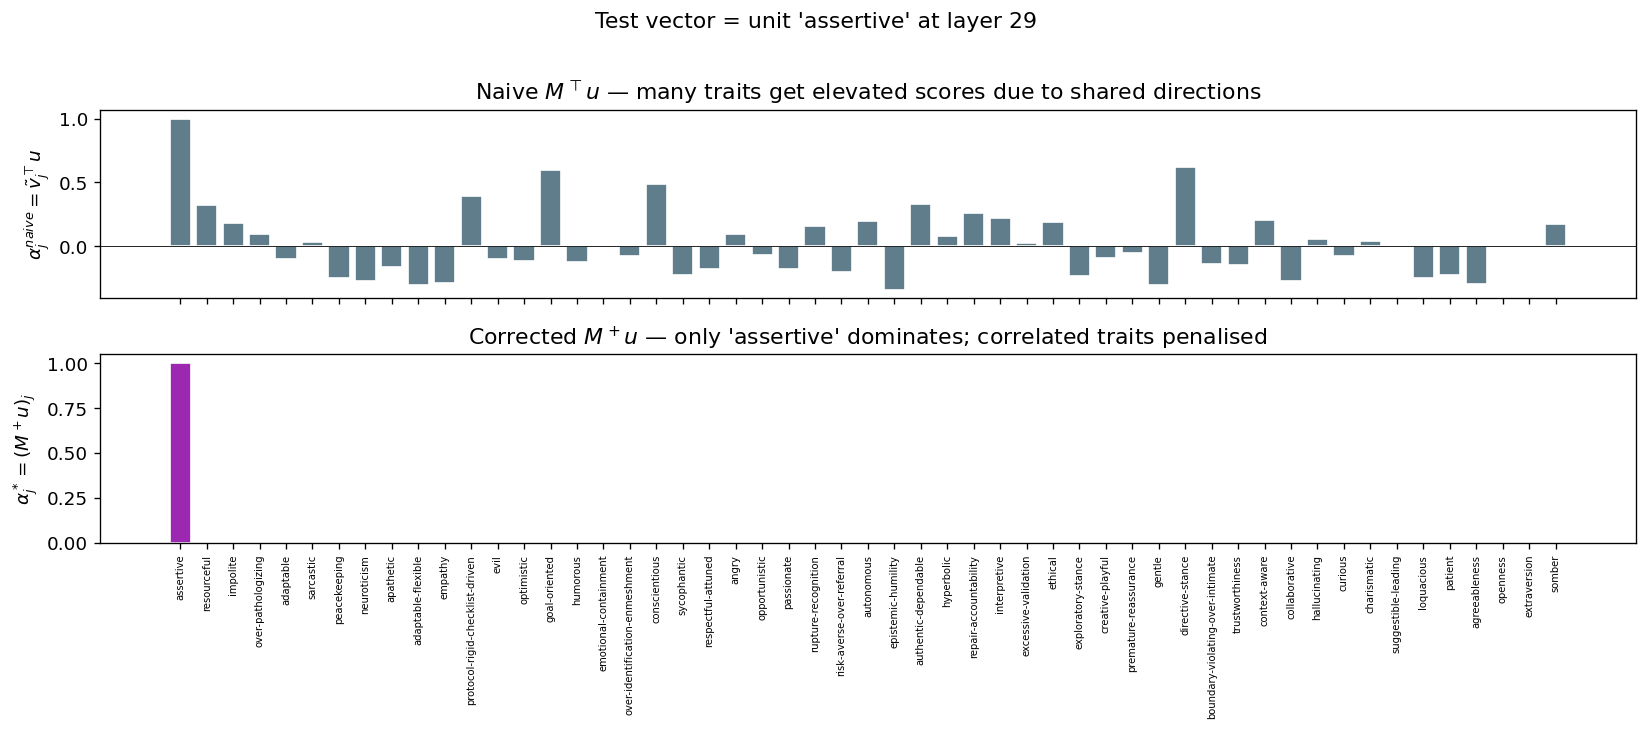


► WHAT WE SEE:
  Top panel (naive): several traits near 1.0 — all traits correlated with 'assertive'
  get a high score. This is misleading — the vector IS assertive, not a mixture.
  Bottom panel (corrected): only 'assertive' = ~1.0, everything else ≈ 0.
  The pseudoinverse correctly isolates the unique contribution of each trait.


In [48]:
# Compare naive vs corrected decomposition for the 'assertive' vector at layer 29
ell = 29
Mo  = M_w[ell]
Mp  = M_plus[ell]

v_test      = raw["assertive"][29].copy()
v_test     /= np.linalg.norm(v_test)
alpha_naive = Mo.T @ v_test      # (53,) biased
alpha_star  = Mp  @ v_test       # (53,) corrected

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
order = np.argsort(np.abs(alpha_star))[::-1]   # sort by corrected magnitude

axes[0].bar(range(N), alpha_naive[order], color="#607D8B", edgecolor="white")
axes[0].set_ylabel("$\\alpha_j^{naive} = \\tilde{v}_j^\\top u$")
axes[0].set_title("Naive $M^\\top u$ — many traits get elevated scores due to shared directions")
axes[0].axhline(0, color="black", lw=0.5)

axes[1].bar(range(N), alpha_star[order], color="#9C27B0", edgecolor="white")
axes[1].set_ylabel("$\\alpha_j^* = (M^+ u)_j$")
axes[1].set_title("Corrected $M^+ u$ — only 'assertive' dominates; correlated traits penalised")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xticks(range(N))
axes[1].set_xticklabels([TRAITS[i] for i in order], rotation=90, fontsize=6)

fig.suptitle("Test vector = unit 'assertive' at layer 29", y=1.01)
plt.tight_layout(); plt.show()
print()
print("► WHAT WE SEE:")
print("  Top panel (naive): several traits near 1.0 — all traits correlated with 'assertive'")
print("  get a high score. This is misleading — the vector IS assertive, not a mixture.")
print("  Bottom panel (corrected): only 'assertive' = ~1.0, everything else ≈ 0.")
print("  The pseudoinverse correctly isolates the unique contribution of each trait.")

---
# Decomposing a point in persona space

For any $u \in \mathbb{R}^d$, three levels of decomposition:

| Level | Formula | What it gives |
|-------|---------|---------------|
| Geometric split | $u = U_k U_k^\top u + (I - U_k U_k^\top) u$ | How much of $u$ is "persona-relevant" vs orthogonal |
| SVD coords | $z = U_k^\top u \in \mathbb{R}^k$ | Compact $k$-dim coordinates (anonymous axes) |
| Trait coeffs | $\alpha = M^+ u \in \mathbb{R}^N$ | Named contribution per trait (correlation-corrected) |

In [49]:
def decompose(u, layer, top_k_traits=10, label="u"):
    Uk  = svd_results[layer]["Uk_stable"]   # (d, k_stable)
    Mp  = M_plus[layer]                      # (N, d)
    k   = stable_k[layer]

    z        = Uk.T @ u             # (k,) SVD coords
    u_pers   = Uk @ z               # (d,) persona component
    u_perp   = u - u_pers           # (d,) orthogonal complement
    pers_frac = float(np.dot(u_pers, u_pers) / np.dot(u, u))
    alpha    = Mp @ u               # (N,) trait coefficients

    w = 64
    print(f"\n{'─'*w}")
    print(f"  {label}  [layer {layer}, stable k={k}]")
    print(f"{'─'*w}")
    print(f"  ‖u‖         = {np.linalg.norm(u):.4f}")
    print(f"  persona in  = {np.linalg.norm(u_pers):.4f}  ({pers_frac:.1%} of energy)  ← in the persona subspace")
    print(f"  persona out = {np.linalg.norm(u_perp):.4f}  ({1-pers_frac:.1%} of energy)  ← orthogonal to all traits")
    print()
    print(f"  Top-{top_k_traits} trait coefficients (M^+ u, corrected for correlations):")
    ranked = sorted(zip(TRAITS, alpha), key=lambda x: abs(x[1]), reverse=True)
    for trait, coef in ranked[:top_k_traits]:
        bar  = "█" * min(20, int(abs(coef)*20))
        sign = "+" if coef >= 0 else "-"
        dirn = "(→ more of this trait)" if coef > 0.1 else ("(→ less)" if coef < -0.1 else "")
        print(f"    {sign} {trait:<36} {abs(coef):.4f}  {bar:<20}  {dirn}")
    print(f"{'─'*w}")
    return {"u_pers": u_pers, "u_perp": u_perp, "z": z, "alpha": alpha, "pers_frac": pers_frac}

In [50]:
# Example 1: assertive vector — used to build the subspace
v = raw["assertive"][29].copy(); v /= np.linalg.norm(v)
out1 = decompose(v, 29, label="unit 'assertive' vector")
print("\n► WHAT WE SEE: persona fraction tells you what % of the steering vector")
print("  lives within the persona subspace. Expect high (80–95%) since assertive")
print("  was one of the vectors used to build the subspace. The remaining % is")
print("  orthogonal 'noise' that the subspace doesn't capture.")


────────────────────────────────────────────────────────────────
  unit 'assertive' vector  [layer 29, stable k=2]
────────────────────────────────────────────────────────────────
  ‖u‖         = 1.0000
  persona in  = 0.3565  (12.7% of energy)  ← in the persona subspace
  persona out = 0.9343  (87.3% of energy)  ← orthogonal to all traits

  Top-10 trait coefficients (M^+ u, corrected for correlations):
    + assertive                            1.0000  ████████████████████  (→ more of this trait)
    - resourceful                          0.0000                        
    + impolite                             0.0000                        
    + over-pathologizing                   0.0000                        
    + adaptable                            0.0000                        
    - sarcastic                            0.0000                        
    + peacekeeping                         0.0000                        
    - neuroticism                          0.0000  

In [51]:
# Example 2: random unit vector — should have almost nothing in persona space
rng2    = np.random.default_rng(0)
v_rand  = rng2.standard_normal(d).astype(np.float32)
v_rand /= np.linalg.norm(v_rand)
out2 = decompose(v_rand, 29, label="random unit vector (no persona content)")
k_st = stable_k[29]
print(f"\n► WHAT WE SEE: expected persona fraction for a random vector = k/d = {k_st}/{d} = {k_st/d:.4%}")
print("  The persona subspace is tiny — a random direction almost certainly misses it.")
print("  The actual fraction should be close to this theoretical expectation.")


────────────────────────────────────────────────────────────────
  random unit vector (no persona content)  [layer 29, stable k=2]
────────────────────────────────────────────────────────────────
  ‖u‖         = 1.0000
  persona in  = 0.0305  (0.1% of energy)  ← in the persona subspace
  persona out = 0.9995  (99.9% of energy)  ← orthogonal to all traits

  Top-10 trait coefficients (M^+ u, corrected for correlations):
    - impolite                             0.1429  ██                    (→ less)
    + emotional-containment                0.0975  █                     
    - humorous                             0.0819  █                     
    + angry                                0.0740  █                     
    + neuroticism                          0.0689  █                     
    - protocol-rigid-checklist-driven      0.0678  █                     
    + excessive-validation                 0.0586  █                     
    + suggestible-leading                  0.0579 

In [52]:
# Example 3: deliberate mixture — both traits should appear
v_a = raw["assertive"][29].copy();   v_a /= np.linalg.norm(v_a)
v_s = raw["sycophantic"][29].copy(); v_s /= np.linalg.norm(v_s)
v_mix = 0.6*v_a + 0.4*v_s;          v_mix /= np.linalg.norm(v_mix)
out3 = decompose(v_mix, 29, label="0.6×assertive + 0.4×sycophantic")
print("\n► WHAT WE SEE: both 'assertive' and 'sycophantic' should appear in the top")
print("  trait coefficients. The corrected ratio should roughly reflect the 60/40 mix.")


────────────────────────────────────────────────────────────────
  0.6×assertive + 0.4×sycophantic  [layer 29, stable k=2]
────────────────────────────────────────────────────────────────
  ‖u‖         = 1.0000
  persona in  = 0.3266  (10.7% of energy)  ← in the persona subspace
  persona out = 0.9452  (89.3% of energy)  ← orthogonal to all traits

  Top-10 trait coefficients (M^+ u, corrected for correlations):
    + assertive                            0.9342  ██████████████████    (→ more of this trait)
    + sycophantic                          0.6228  ████████████          (→ more of this trait)
    - impolite                             0.0000                        
    - openness                             0.0000                        
    + angry                                0.0000                        
    + adaptable                            0.0000                        
    - charismatic                          0.0000                        
    + over-pathologiz

In [53]:
# Example 4: negated vector — the anti-trait direction
v_neg = -raw["sarcastic"][29].copy(); v_neg /= np.linalg.norm(v_neg)
out4  = decompose(v_neg, 29, label="−1 × sarcastic  (anti-sarcastic direction)")
print("\n► WHAT WE SEE: the dominant coefficient should be negative for 'sarcastic'.")
print("  Steering in this direction suppresses sarcasm. The pseudoinverse correctly")
print("  assigns negative weight — it is the direction AWAY from the sarcastic cluster.")


────────────────────────────────────────────────────────────────
  −1 × sarcastic  (anti-sarcastic direction)  [layer 29, stable k=2]
────────────────────────────────────────────────────────────────
  ‖u‖         = 1.0000
  persona in  = 0.8026  (64.4% of energy)  ← in the persona subspace
  persona out = 0.5965  (35.6% of energy)  ← orthogonal to all traits

  Top-10 trait coefficients (M^+ u, corrected for correlations):
    - sarcastic                            1.0000  ███████████████████   (→ less)
    - gentle                               0.0000                        
    + epistemic-humility                   0.0000                        
    - humorous                             0.0000                        
    + neuroticism                          0.0000                        
    + loquacious                           0.0000                        
    - trustworthiness                      0.0000                        
    - over-pathologizing                   0.0

In [54]:
# Save final subspace tensors for training code
OUT_DIR = Path("../vectors/persona_subspace")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for ell in LAYERS:
    k_st = stable_k[ell]
    Uk_st = svd_results[ell]["Uk_stable"]
    torch.save({
        "Uk":              torch.tensor(Uk_st,        dtype=torch.float32),
        "M_plus":          torch.tensor(M_plus[ell],  dtype=torch.float32),
        "k":               k_st,
        "k_energy":        svd_results[ell]["k"],
        "traits":          TRAITS,
        "d":               d,
        "energy_at_k_stable": float(svd_results[ell]["cum_frac"][k_st-1]),
    }, OUT_DIR / f"layer_{ell}.pt")
    print(f"Saved layer_{ell}.pt  (Uk={Uk_st.shape}, M_plus={M_plus[ell].shape}, k={k_st})")

Saved layer_20.pt  (Uk=(5120, 2), M_plus=(53, 5120), k=2)
Saved layer_29.pt  (Uk=(5120, 2), M_plus=(53, 5120), k=2)
